In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import BallStickZeppelinNoise
from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx



sim_type = BallStickZeppelinNoise
ball_stick = sim_type.from_theta(np.random.randn(sim_type.theta_dim))

In [3]:

@jax.jit
def simulator(rng):
    rng0, rng1, rng2, rng3, rng4, rng5 = jax.random.split(rng, 6)
    rng0_1, rng0_2 = jax.random.split(rng0)
    bvals1 = jax.random.choice(rng0_1, jnp.array(list(range(0, 2100, 100))), shape=(160,))
    bvals1 = jnp.sort(bvals1)
    bvals2 = jnp.array([0]*10 + [2000]*150)
    bvals = jax.random.choice(rng0_2, jnp.stack([bvals1, bvals2], axis=0))
    bvecs = jax.random.normal(rng3, shape=(160, 3))
    bvecs = bvecs / jnp.linalg.norm(bvecs, axis=-1, keepdims=True)
    acq = acquisition_scheme(bvals, bvecs)
    theta = jax.random.normal(rng1, shape=(sim_type.theta_dim,))
    rng_p, rng_m = jax.random.split(rng2)
    p_mask = jax.random.beta(rng_p, a=1, b=1, shape=(1,))
    model_mask = jax.random.bernoulli(rng_m, p=p_mask, shape=(len(sim_type.model_types)))
    # This needs to have only one entry
    model_noise_idx = jax.random.randint(rng4, minval=0, maxval=len(sim_type.noise_types), shape=(1,))
    model_noise_mask = jnp.zeros(len(sim_type.noise_types), dtype=jnp.bool)
    model_noise_mask = model_noise_mask.at[model_noise_idx].set(True)
    model_mask = jnp.concatenate([model_mask, model_noise_mask], axis=-1)
    ball_stick = sim_type.from_theta(theta, model_mask=model_mask)

    x_o = ball_stick.signal(acq, rng=rng5)
    return p_mask, model_mask, theta, x_o, acq


In [10]:
masks.shape, theta.shape, x_o.shape, acq.bvals.shape, acq.bvecs.shape, p_mask.shape

((200, 5), (200, 12), (200, 160), (200, 160), (200, 160, 3), (200, 1))

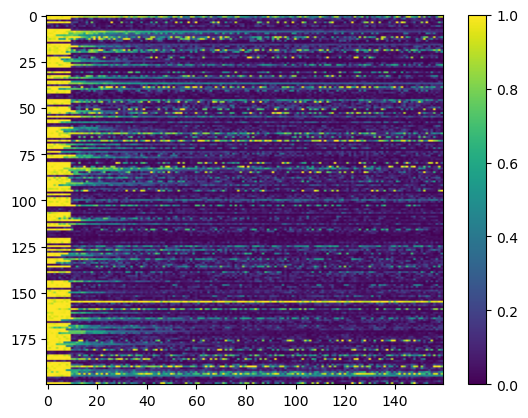

In [4]:
p_mask,masks, theta, x_o, acq = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=200))

plt.imshow(x_o, aspect='auto', vmin=0, vmax=1)
plt.colorbar()

In [8]:
from dmri.nn.dmri_reconstruction_model import DMRIInferenceModel, DMRIInferenceModelConfig, DMRIInferenceModelConfigMaskPriorAmortized

cfg = DMRIInferenceModelConfigMaskPriorAmortized(sim_type)
cfg.embedding_cfg.dropout_rate = 0.1
model = DMRIInferenceModel(cfg, nnx.Rngs(1))

params = nnx.state(model, nnx.Param)
model.train()

In [22]:
model.tokenizer.model_types_to_idx.value

{'Ball': [0], 'Stick': [1], 'Zeppelin': [2]}

In [9]:
model(masks, theta, x_o, acq.bvals, acq.bvecs, p_mask)[0][0]

(0, 1, 2, 3, 4)


Array([-2.274, -1.011, -0.455, -1.892, -1.987], dtype=float32)

In [20]:
nnx.display(model)

In [8]:
import optax

scheduler = optax.cosine_onecycle_schedule(100*500, 5e-4)
optimizer = optax.chain(optax.adaptive_grad_clip(50.), optax.ema(0.01), optax.adamw(scheduler))

opt_state = optimizer.init(params)


In [9]:

def loss_fn(params, data, rng):
    nnx.update(model, params)
    p_mask, model_mask, thetas,  xs, bvals, bvecs = data
    return model.loss_fn(params, rng,model_mask=model_mask, theta=thetas, x=xs,bvals=bvals, bvecs=bvecs, mask_prior=p_mask).sum()


@jax.jit
def update(params, opt_state, data, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, data, rng)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [10]:
batch_simulator = jax.jit(jax.vmap(simulator))

In [11]:
key = jax.random.PRNGKey(42)
for i in range(100):
    key, subkey1 = jax.random.split(key, 2)
    p_mask, masks, thetas, x_os, acq = batch_simulator(jax.random.split(subkey1, 2**16))
    l = 0
    for j in range(50):
        key, subkey2 = jax.random.split(key, 2)
        idx = jax.random.randint(subkey2, (128,), 0, 2**16)
        p_mask_batch, masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch = p_mask[idx],masks[idx], thetas[idx], x_os[idx], acq.bvals[idx], acq.bvecs[idx]
        params, opt_state, loss = update(params, opt_state, (p_mask_batch,masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch), subkey2)
        l += loss
    print(l/50)

(0, 1, 2, 3, 4)


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fa6a59bccd0>>
Traceback (most recent call last):
  File "/root/miniconda3/envs/dipy/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


6.30928


2025-03-24 10:31:53.251019: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.77GiB (rounded to 2971110400)requested by op 
2025-03-24 10:31:53.252172: W external/xla/xla/tsl/framework/bfc_allocator.cc:512] *______*******______________________________________________________________________________________
E0324 10:31:53.253380    6024 pjrt_stream_executor_client.cc:3077] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 2971110336 bytes. [tf-allocator-allocation-error='']


ValueError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 2971110336 bytes.

In [88]:
opt_state = optimizer.init(params)

In [89]:
key = jax.random.PRNGKey(43)
for i in range(100):
    key, subkey1 = jax.random.split(key, 2)
    p_mask, masks, thetas, x_os, acq = batch_simulator(jax.random.split(subkey1, 2**16))
    l = 0
    for j in range(500):
        key, subkey2 = jax.random.split(key, 2)
        idx = jax.random.randint(subkey2, (512,), 0, 2**16)
        p_mask_batch, masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch = p_mask[idx],masks[idx], thetas[idx], x_os[idx], acq.bvals[idx], acq.bvecs[idx]
        params, opt_state, loss = update(params, opt_state, (p_mask_batch,masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch), subkey2)
        l += loss
    print(l/500)

(0, 1, 2, 3, 4)
3.3424122
3.3388278
3.3438647
3.350548
3.343329
3.3492074
3.3433266
3.344163
3.3509595
3.3546517
3.355834
3.3621576
3.3660433
3.373806
3.3800874
3.381445
3.3746684
3.377484
3.4230905
3.3936875
3.404967
3.3928604
3.3992558
3.401418
3.3978522
3.406068
3.4017105
3.3914232
3.4717958
3.4254003
3.4399605
3.4192722
3.4070203
3.3924487
3.4016802
3.3846512
3.3874304
3.397264
3.3885994
3.3858724
3.3884814
3.3720233
3.364071
3.3622742
3.3543906
3.3802006
3.4225974
3.3855176
3.357601
3.3745205
3.3535037
3.3503435
3.350359
3.342545
3.3369093
3.3410125
3.3349562
3.323703
3.3317604
3.3198013
3.3206277
3.32339
3.3241603
3.3120513
3.3176785
3.314523
3.3094
3.306762
3.2924519
3.2932763
3.2981849
3.3052502
3.2921395
3.2957284
3.2867923
3.2876816
3.2872715
3.27921
3.280322
3.2796981
3.2761004
3.2747197
3.2672036
3.2741013
3.269554
3.272213
3.2688172
3.2694356
3.2686474
3.2676747
3.2710488
3.2741208
3.270319
3.265615
3.2725062
3.258735
3.2628334
3.258779
3.2681756
3.2750993


In [32]:
nnx.update(model, params)

In [43]:
from functools import partial


@jax.jit
def sample_masks(params, rng, data):
    nnx.update(model, params)
    p_mask, model_mask, thetas,  xs, acq = data
    sample_fn = jax.vmap(model.sample_mask)
    rngs = jax.random.split(rng, len(thetas))
    masks_sampled = sample_fn(rngs, acq.bvals, acq.bvecs, xs, p_mask)
    return masks_sampled

@jax.jit
def log_prob_true(params, data):
    nnx.update(model, params)
    p_mask, model_mask, thetas,  xs, acq = data
    return jax.vmap(model.log_prob_mask)(model_mask, acq.bvals, acq.bvecs, xs, p_mask)

@jax.jit
def sample_theta(params, rng, data, num_steps=128, max_noise=40):
    nnx.update(model, params)
    p_mask, model_mask, thetas,  xs, acq = data
    sample_fn = jax.vmap(model.sample_theta)
    rngs = jax.random.split(rng, len(thetas))
    sample_fn = jax.vmap(partial(model.sample_theta, num_steps=num_steps, max_noise=max_noise))
    return sample_fn(rngs, acq.bvals, acq.bvecs, xs, model_mask)

@jax.jit
def log_prob_theta(params, data, num_steps=128, max_noise=40):
    nnx.update(model, params)
    p_mask, model_mask, thetas,  xs, acq = data
    sample_fn = partial(model.log_prob_theta, num_steps=num_steps, max_noise=max_noise)
    return jax.vmap(sample_fn)(thetas, acq.bvals, acq.bvecs, xs, model_mask)

@jax.jit
def sample_and_log_prob_theta(params, rng, data, num_steps=128, max_noise=40):
    nnx.update(model, params)
    _, model_mask, _,  xs, acq = data
    rngs = jax.random.split(rng, xs.shape[0])
    thetas, log_probs = jax.vmap(partial(model.sample_and_log_prob_theta, num_steps=num_steps, max_noise=max_noise))(rngs, acq.bvals, acq.bvecs, xs, model_mask)
    return thetas, log_probs

In [36]:
p_mask, masks, thetas, x_os, acq = batch_simulator(jax.random.split(jax.random.key(0), 100))
masks_sampled = sample_masks(params, jax.random.key(0), (p_mask, masks, thetas, x_os, acq))

UnexpectedTracerError: Encountered an unexpected tracer. A function transformed by JAX had a side effect, allowing for a reference to an intermediate value with type float32[3,64] wrapped in a DynamicJaxprTracer to escape the scope of the transformation.
JAX transformations require that functions explicitly return their outputs, and disallow saving intermediate values to global state.
The function being traced when the value leaked was sample_masks at /tmp/ipykernel_12356/178857557.py:4 traced for jit.
------------------------------
The leaked intermediate value was created on line /tmp/ipykernel_12356/3665714183.py:2:16 (<module>). 
------------------------------
When the value was created, the final 5 stack frames (most recent last) excluding JAX-internal frames were:
------------------------------
<frozen runpy>:198:11 (_run_module_as_main)
<frozen runpy>:88:4 (_run_code)
/tmp/ipykernel_12356/3665714183.py:2:16 (<module>)
------------------------------

To catch the leak earlier, tr

In [44]:
log_prob_true(params, (p_mask, masks, thetas, x_os, acq)).mean()

(0, 1, 2, 3, 4)


Array(-27.711, dtype=float32)

In [45]:
theta = sample_theta(params, jax.random.key(0), (p_mask, masks, thetas, x_os, acq))

(0, 1, 2, 3, 4)


In [46]:
log_probs = log_prob_theta(params, (p_mask, masks, thetas, x_os, acq))

(0, 1, 2, 3, 4)


In [50]:
theta, log_probs = sample_and_log_prob_theta(params, jax.random.key(0), (p_mask, masks, thetas, x_os, acq))

In [55]:
thetas_for_batch, log_probs_for_batch = jax.vmap(lambda k: sample_and_log_prob_theta(params, k, (p_mask, masks, thetas, x_os, acq)))(jax.random.split(jax.random.key(0), 10))

In [58]:
thetas_for_batch.shape

(10, 100, 12)

In [11]:
# import pickle

# with open('params_small.pkl', 'wb') as f:
#     pickle.dump(params, f)

In [35]:
import pickle
with open('params_small.pkl', 'rb') as f:
    params = pickle.load(f)
nnx.update(model, params)

In [12]:
p_mask, masks, thetas, x_os, acq = batch_simulator(jax.random.split(jax.random.key(0), 100))

In [13]:
#idx = 2
idx = 11

In [14]:
mask = jax.vmap(model.sample_mask, in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 128), acq.bvals[idx], acq.bvecs[idx], x_os[idx], jnp.array([0.3]))

(0, 1, 2, 3, 4)


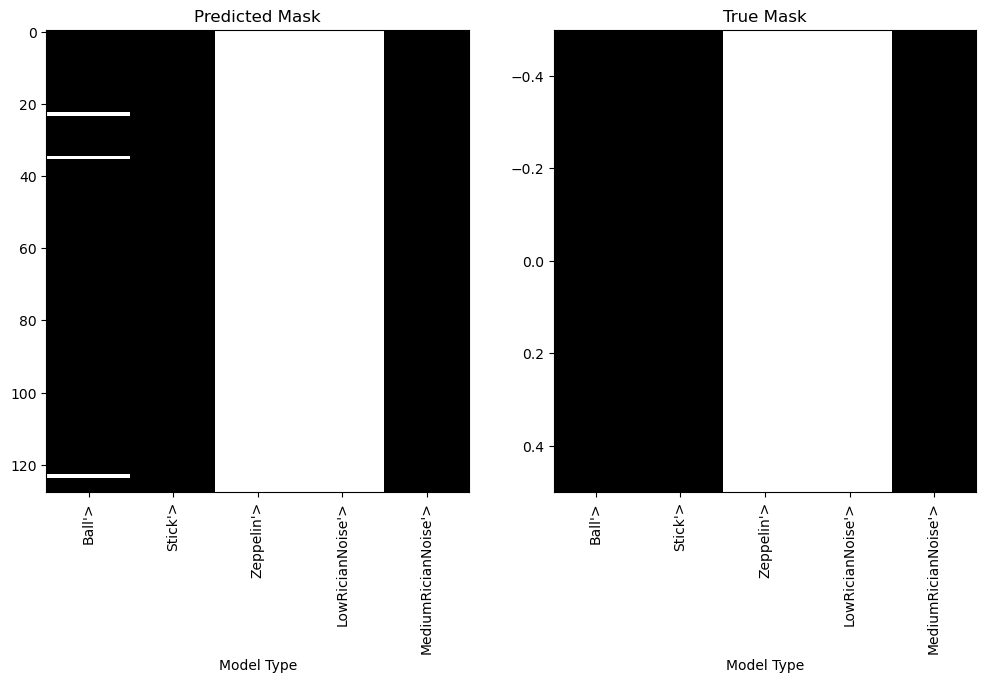

In [15]:
plt.figure(figsize=(12, 6))

# Plot predicted mask
plt.subplot(1, 2, 1)
plt.imshow(mask, aspect='auto', cmap='gray', vmin=0, vmax=1)
plt.title('Predicted Mask')
plt.xlabel('Model Type')
plt.xticks(range(len(sim_type.model_types) + len(sim_type.noise_types)), [str(m).split(".")[-1] for m in sim_type.model_types] + [str(m).split(".")[-1] for m in sim_type.noise_types], rotation=90)

# Plot true mask
mask_true = masks[idx]
plt.subplot(1, 2, 2)
plt.imshow(mask_true[None], aspect='auto', cmap='gray', vmin=0, vmax=1)
plt.title('True Mask')
plt.xlabel('Model Type')
plt.xticks(range(len(sim_type.model_types) + len(sim_type.noise_types)), [str(m).split(".")[-1] for m in sim_type.model_types] + [str(m).split(".")[-1] for m in sim_type.noise_types], rotation=90)

plt.show()

In [16]:
from functools import partial

In [17]:
thetas_post = jax.vmap(partial(model.sample_theta, num_steps=128, max_noise=20), in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 4096), acq.bvals[idx], acq.bvecs[idx], x_os[idx],masks[idx])

(0, 1, 2, 3, 4)


In [12]:
import sbi
from sbi.analysis.plot import pairplot

_ = pairplot(thetas_post, points=[thetas[idx],], limits=[[-3,3]*100], labels=[f'$\\theta_{i}$' for i in range(100)], figsize=(25, 25))

AttributeError: `np.obj2sctype` was removed in the NumPy 2.0 release. Use `np.dtype(obj).type` instead.

In [17]:
def posterior_pred(theta,rng):
    return sim_type.from_theta(theta, model_mask=masks[idx]).signal(acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), rng=rng)

def loglikelihood(theta):
    simulator = sim_type.from_theta(theta, model_mask=masks[idx])
    ll = simulator.log_likelihood(acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), x_os[idx])
    return ll

posterior_preds = jax.vmap(posterior_pred)(thetas_post, jax.random.split(jax.random.key(0), 4096))

In [42]:
ll = loglikelihood(thetas[idx])

In [ ]:
with jax.default_device(jax.devices('cpu')[0]):
    sigma = 0.001
    eps = sigma*jax.random.normal(jax.random.key(0), shape=(1000000, sim_type.theta_dim,))
    ll_perturbed = jax.vmap(loglikelihood)(thetas[idx][None] + eps)

In [ ]:
grad_est = jnp.mean((ll_perturbed - ll)[:,None]  * eps, axis=0)/sigma**2
grad_est

Array([  0.025,  -0.031,   0.05 ,   0.049,  -0.115,   0.122, -17.89 ,
        92.611,   5.037,  -0.91 ,  -0.129,   0.174], dtype=float32)

In [113]:
jax.grad(loglikelihood)(thetas[idx])

(3, 2) (3,)


Array([  0.   ,   0.   ,   0.   ,   0.   ,   0.   ,   0.   , -17.88 ,
        92.679,   5.158,  -1.032,  -0.218,   0.   ], dtype=float32)

In [34]:
eps_idx = model(model_mask=masks, theta=thetas, x=x_os, bvals=acq.bvals, bvecs=acq.bvecs, mask_prior=p_mask, t=jnp.ones_like(p_mask)*0.0001)[-1][idx]

(0, 1, 2, 3, 4)


Array([  0.024,   0.292,  -0.095,   0.024,   0.072,   0.061, -12.41 ,
        -9.066,  11.408,  -1.645,   7.248,   0.012], dtype=float32)

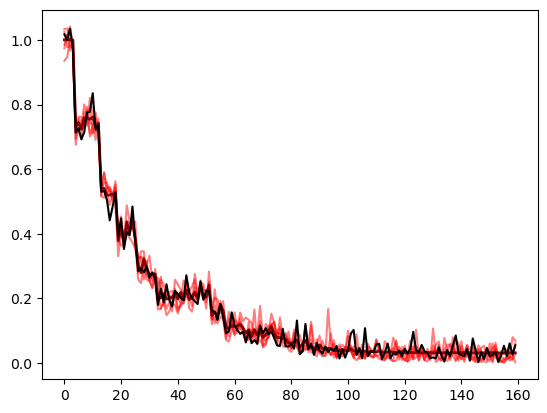

In [157]:
_ = plt.plot(posterior_preds[:5].T, label="posterior pred", color="red", alpha=0.5)
_ = plt.plot(posterior_preds.mean(0).T, label="posterior pred mean", color="darkred", linewidth=2)
_ = plt.plot(x_os[idx], label="data", color="black")

In [158]:
def log_posterior(theta):
    return loglikelihood(theta) + jax.scipy.stats.norm.logpdf(theta, 0, 1).sum()

def log_q(theta):
    return model.log_prob_theta(theta, acq.bvals[idx], acq.bvecs[idx], x_os[idx], masks[idx], num_steps=32, max_noise=20)

@jax.jit
def effectve_sample_size(thetas):
    logp = jax.vmap(log_posterior)(thetas)
    logq = jax.vmap(log_q)(thetas)
    log_w = logp - logq
    # Self normalized importance weights
    w = jax.nn.softmax(log_w)
    return 1/jnp.sum(w**2)


In [159]:
effectve_sample_size(thetas_post)

(0, 1, 2, 3, 4)


Array(174.767, dtype=float32)

In [142]:
logp = jax.vmap(log_posterior)(thetas_post)
logq = jax.vmap(log_q)(thetas_post)
log_w = logp - logq
# Self normalized importance weights
w = jax.nn.softmax(log_w)

(0, 1, 2, 3, 4)


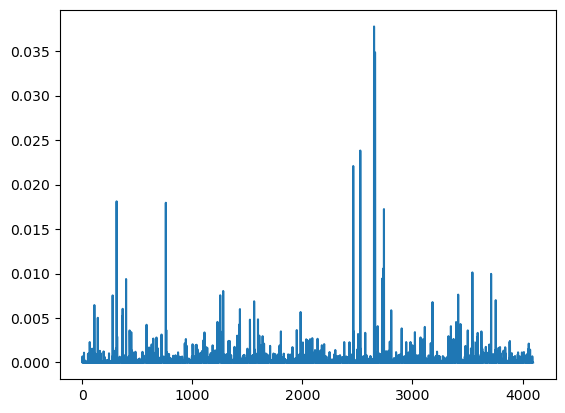

In [143]:
plt.plot(w)

In [8]:
from dipy.data import get_fnames
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti
hardi_fname, hardi_bval_fname, hardi_bvec_fname = get_fnames(name="stanford_hardi")

data, affine = load_nifti(hardi_fname)

bvals, bvecs = read_bvals_bvecs(hardi_bval_fname, hardi_bvec_fname)


In [9]:
from dipy.segment.mask import median_otsu

datamask, mask = median_otsu(
    data, vol_idx=range(10, 50), median_radius=3, numpass=1, autocrop=True, dilate=2
)
b0_mask = bvals == 0

In [10]:
# Data sub
S0 = np.mean(datamask[..., b0_mask], -1)
data_norm = datamask / S0[..., None]
x_o = data_norm[13:43, 44:74, 28:29].squeeze()
S_o = S0[13:43, 44:74, 28:29].squeeze()


/tmp/ipykernel_12724/3122232576.py:3: RuntimeWarning: divide by zero encountered in divide
  data_norm = datamask / S0[..., None]
/tmp/ipykernel_12724/3122232576.py:3: RuntimeWarning: invalid value encountered in divide
  data_norm = datamask / S0[..., None]


Text(0.5, 1.0, 'HCP coronal slice B0 with ROI')

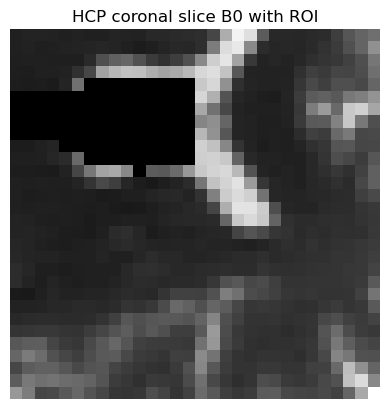

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
%matplotlib inline

fig, ax = plt.subplots(1)
ax.imshow(S_o, cmap='gray', origin='lower')
ax.set_axis_off()
ax.set_title('HCP coronal slice B0 with ROI')

In [12]:
acq = acquisition_scheme(jnp.array(bvals), jnp.array(bvecs))

In [13]:
sample_mask_per_x= jax.jit(jax.vmap(lambda k, x: model.sample_mask(k, acq.bvals, acq.bvecs, x), in_axes=(0,0)))
x_o_flat = x_o.reshape(-1, x_o.shape[-1])

mask = sample_mask_per_x(jax.random.split(jax.random.key(0), x_o_flat.shape[0]), x_o_flat).astype(jnp.float32)
for i in range(1,100):
    mask += sample_mask_per_x(jax.random.split(jax.random.key(i), x_o_flat.shape[0]), x_o_flat).astype(jnp.float32)
p_models = mask / 100

(0, 1, 2, 3, 4)


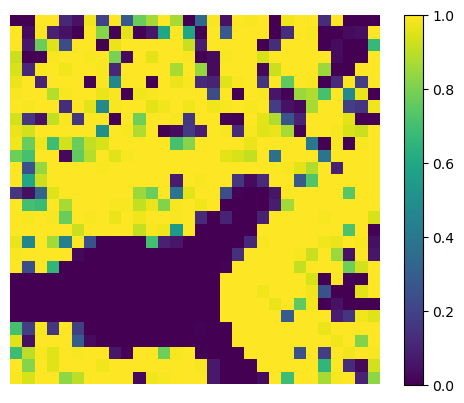

In [14]:
fig, ax = plt.subplots(1)
l = ax.imshow(p_models[:,4].reshape(30,30), vmin=0,vmax=1.)
ax.set_axis_off()
plt.colorbar(l)

In [30]:
model_mask = jnp.array([True, True, False, True, False], dtype=jnp.bool)
sample_theta_per_x = jax.jit(jax.vmap(lambda k, x: model.sample_theta(k, acq.bvals, acq.bvecs, x, model_mask, num_steps=64, max_noise=40), in_axes=(0,0)))

thetas = []
for i in range(10):
    thetas.append(sample_theta_per_x(jax.random.split(jax.random.key(i), x_o_flat.shape[0]), x_o_flat))


(0, 1, 2, 3, 4)


In [29]:

def sim_theta(key, theta):
    simulator = sim_type.from_theta(theta, model_mask=model_mask)
    x_pred = simulator.signal(acq, rng=key)
    return x_pred

x_preds = jax.vmap(sim_theta)(jax.random.split(jax.random.key(0), thetas[0].shape[0]), thetas[3])
i = 13
plt.plot(x_o_flat[i], label="data")
plt.plot(x_preds[i], label="pred")

NameError: name 'thetas' is not defined

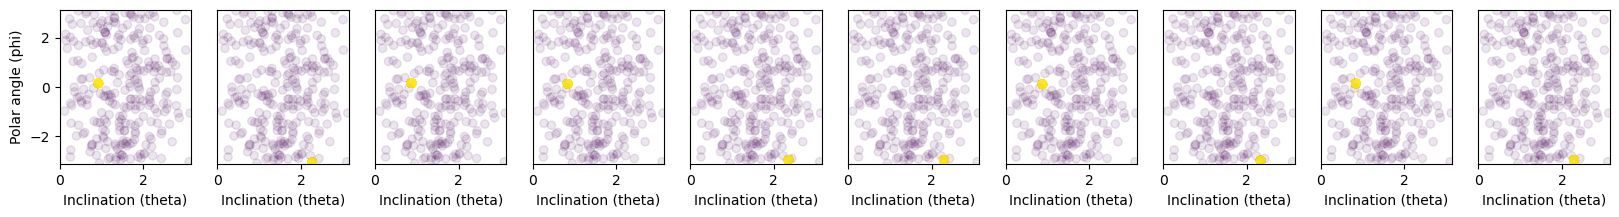

In [35]:
fig, axes = plt.subplots(1, 10, figsize=(20, 2))

for j in range(10):
    fod = sim_type.from_theta(thetas[j][i], model_mask=model_mask).to_fod()
    fod.viz(plot_type="polar",n_samples=5_00, ax=axes[j])
    if j > 0:
        axes[j].set_ylabel("")
        axes[j].set_yticks([])

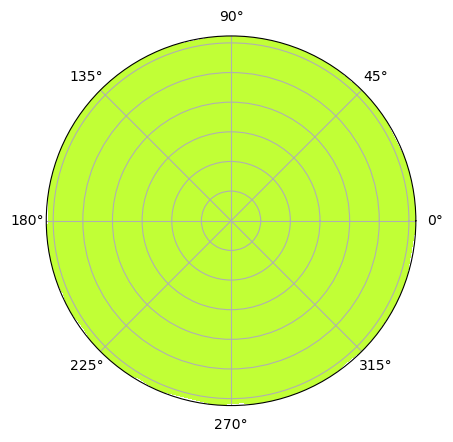

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

#fake data:
samples = fod.sample(jax.random.PRNGKey(0), (100,))
# Samples to polar coordinates
theta = np.arctan2(samples[:,1], samples[:,0])
phi = np.arccos(samples[:,2])
a = np.linspace(0,2*np.pi,20)
b = np.linspace(0,1,20)
a = np.concatenate([a, theta])
b = np.concatenate([b, phi])
a = np.sort(a)
b = np.sort(b)
N = a.shape[0]
A, B = np.meshgrid(a, b)
pos_flat = np.vstack([A.ravel(), B.ravel()])
pos_flat_cart = np.vstack([np.cos(A.ravel()), np.sin(A.ravel()), B.ravel()]).T
c = fod.pdf(pos_flat_cart).reshape(N,N)

#actual plotting
ax = plt.subplot(111, polar=True)
ax.set_yticklabels([])
ctf = ax.contourf(a, b, c, cmap=cm.jet)

In [50]:
c.max()

Array(0.043, dtype=float32)

In [68]:
def to_params_dict(theta):
    simulator = sim_type.from_theta(theta, model_mask=model_mask)
    fractions = simulator.model_fractions
    components = simulator.model_compartments
    noise = simulator.noise_compartments

    com_params = [c.params for c in components]
    noise_params = [n.params for n in noise]
    return {"fractions": fractions, "components": com_params, "noise": noise_params}

In [69]:
from dmri.utils.dmriutils import unitsphere_to_cartesian


all_params = jax.vmap(to_params_dict)(thetas[0])
frac = all_params["fractions"]
lam_iso = all_params["components"][0]["lam"]
lam_par = all_params["components"][1]["lam_par"]
mu = all_params["components"][1]["mu"]
direction = jax.vmap(unitsphere_to_cartesian)(mu)


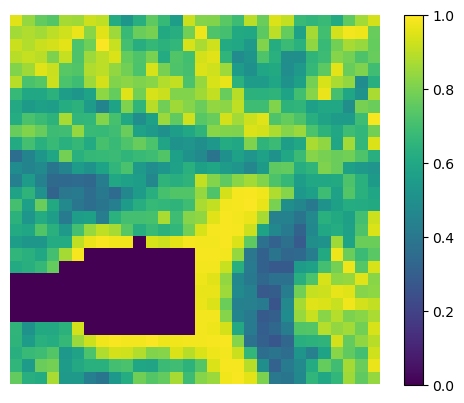

In [73]:
fig, ax = plt.subplots(1)
l = ax.imshow(frac[:,0].reshape(30,30), vmin=0,vmax=1.)
ax.set_axis_off()
plt.colorbar(l)

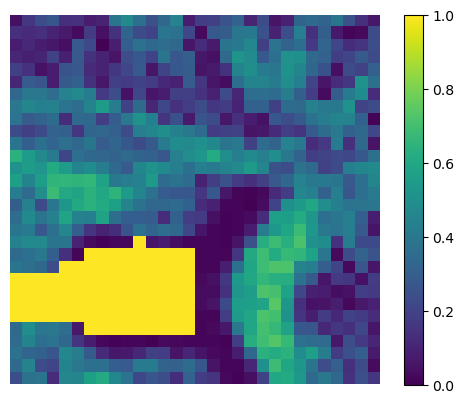

In [78]:
fig, ax = plt.subplots(1)
l = ax.imshow(frac[:,1].reshape(30,30), vmin=0,vmax=1.)
ax.set_axis_off()
plt.colorbar(l)

In [79]:


all_params = jax.vmap(to_params_dict)(thetas[0])
frac = all_params["fractions"]
lam_iso = all_params["components"][0]["lam"]
lam_par = all_params["components"][1]["lam_par"]
mu = all_params["components"][1]["mu"]
direction = jax.vmap(unitsphere_to_cartesian)(mu)

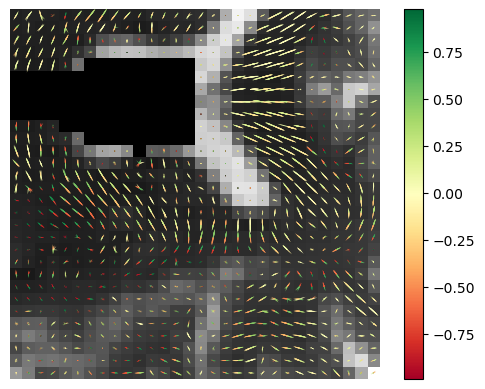

In [80]:
fig, ax = plt.subplots(1)
ax.imshow(S_o.reshape(30, 30), cmap='gray', origin='lower')


for i in range(10):
    # For example, use the first sample in thetas
    all_params = jax.vmap(to_params_dict)(thetas[i])
    frac    = all_params["fractions"]
    lam_par = all_params["components"][1]["lam_par"]
    mu      = all_params["components"][1]["mu"]

    # Convert unit sphere directions to 3D cartesian coordinates.
    direction = jax.vmap(unitsphere_to_cartesian)(mu)
    # Compute 2D projection using the first two components.
    direction_2d = direction[:, :2] * frac[:, 1][:, None] * (lam_par[:, None] > 0)

    # Use the third component (z) as the color code.
    colors = direction[:, 2]

    # Create a grid for quiver
    X, Y = np.meshgrid(np.arange(30), np.arange(30))
    q = ax.quiver(X, Y, direction_2d[:, 0].reshape(30, 30),
                  direction_2d[:, 1].reshape(30, 30),
                  colors.reshape(30, 30), cmap="RdYlGn", scale=25, headwidth=0, headlength=0)
plt.colorbar(q)
ax.set_axis_off()
plt.show()

In [92]:
# Ball and Zeppelins

model_mask = jnp.array([True, True, True, False, True], dtype=jnp.bool)
sample_theta_per_x = jax.jit(jax.vmap(lambda k, x: model.sample_theta(k, acq.bvals, acq.bvecs, x, model_mask, num_steps=128, max_noise=80), in_axes=(0,0)))

thetas = []
for i in range(10):
    thetas.append(sample_theta_per_x(jax.random.split(jax.random.key(i), x_o_flat.shape[0]), x_o_flat))

def sim_theta(key, theta):
    simulator = sim_type.from_theta(theta, model_mask=model_mask)
    x_pred = simulator.signal(acq, rng=key)
    return x_pred


(0, 1, 2, 3, 4)


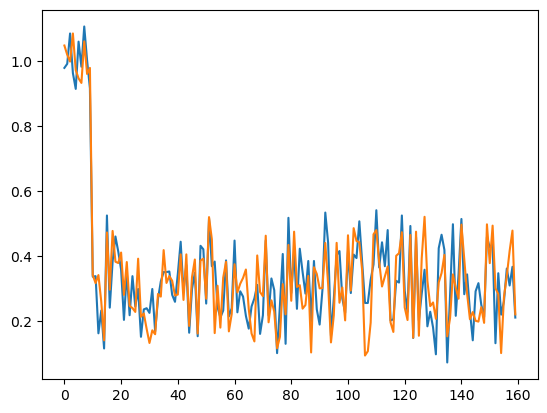

In [106]:
x_preds = jax.vmap(sim_theta)(jax.random.split(jax.random.key(0), thetas[0].shape[0]), thetas[3])

i = 13
plt.plot(x_o_flat[i], label="data")
plt.plot(x_preds[i], label="pred")

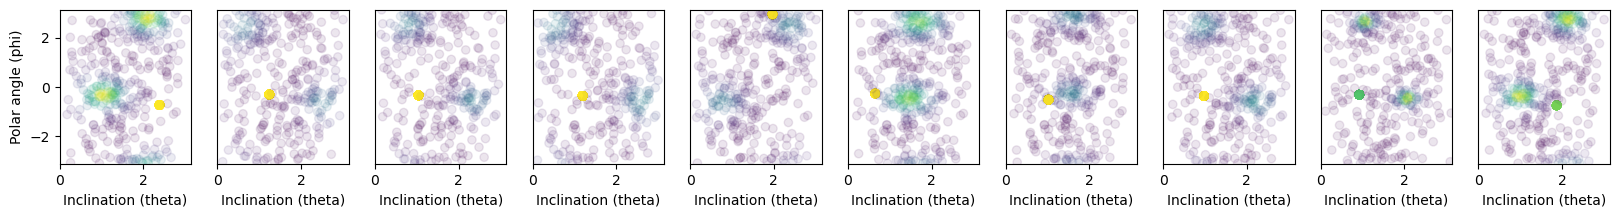

In [107]:
fig, axes = plt.subplots(1, 10, figsize=(20, 2))

for j in range(10):
    fod = sim_type.from_theta(thetas[j][i], model_mask=model_mask).to_fod()
    fod.viz(plot_type="polar",n_samples=5_00, ax=axes[j])
    if j > 0:
        axes[j].set_ylabel("")
        axes[j].set_yticks([])

In [108]:
def to_fod_sample(theta, rng):
    simulator = sim_type.from_theta(theta, model_mask=model_mask)
    fod = simulator.to_fod()
    return fod.fractions, fod.sample(rng, shape=(20,))

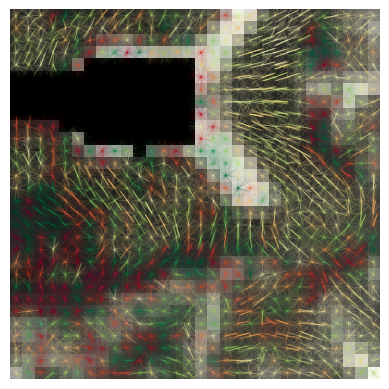

In [109]:
fig, ax = plt.subplots(1)
ax.imshow(S_o.reshape(30, 30), cmap='gray', origin='lower')

for i in range(6):
    theta = thetas[i]
    fractions, directions = jax.vmap(to_fod_sample)(theta, jax.random.split(jax.random.key(i), theta.shape[0]))
    for i in range(20):
        direction_2d = directions[:, i,:2]

        # Use the third component (z) as the color code.
        colors = direction[:, 2]

        # Create a grid for quiver
        X, Y = np.meshgrid(np.arange(30), np.arange(30))
        q = ax.quiver(X, Y, direction_2d[:, 0].reshape(30, 30),
                    direction_2d[:, 1].reshape(30, 30),
                    colors.reshape(30, 30), cmap="RdYlGn", scale=25, headwidth=0, headlength=0, alpha=0.05)
ax.set_axis_off()
plt.show()

In [1]:
from dipy.core.gradients import gradient_table
from dipy.data import default_sphere, get_fnames, small_sphere
from dipy.direction import ProbabilisticDirectionGetter, peaks_from_model
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti, load_nifti_data
from dipy.io.stateful_tractogram import Space, StatefulTractogram
from dipy.io.streamline import save_trk
from dipy.reconst.csdeconv import ConstrainedSphericalDeconvModel, auto_response_ssst
from dipy.reconst.shm import CsaOdfModel
from dipy.tracking import utils
from dipy.tracking.local_tracking import LocalTracking
from dipy.tracking.stopping_criterion import ThresholdStoppingCriterion
from dipy.tracking.streamline import Streamlines
from dipy.viz import actor, colormap, has_fury, window

# Enables/disables interactive visualization
interactive = False

hardi_fname, hardi_bval_fname, hardi_bvec_fname = get_fnames(name="stanford_hardi")
label_fname = get_fnames(name="stanford_labels")

data, affine, hardi_img = load_nifti(hardi_fname, return_img=True)
labels = load_nifti_data(label_fname)
bvals, bvecs = read_bvals_bvecs(hardi_bval_fname, hardi_bvec_fname)
gtab = gradient_table(bvals, bvecs=bvecs)

seed_mask = labels == 2
white_matter = (labels == 1) | (labels == 2)
seeds = utils.seeds_from_mask(seed_mask, affine, density=1)

response, ratio = auto_response_ssst(gtab, data, roi_radii=10, fa_thr=0.7)
csd_model = ConstrainedSphericalDeconvModel(gtab, response, sh_order_max=6)
csd_fit = csd_model.fit(data, mask=white_matter)

In [2]:
csa_model = CsaOdfModel(gtab, sh_order_max=6)
gfa = csa_model.fit(data, mask=white_matter).gfa
stopping_criterion = ThresholdStoppingCriterion(gfa, 0.25)

In [3]:


fod = csd_fit.odf(small_sphere)
pmf = fod.clip(min=0)
prob_dg = ProbabilisticDirectionGetter.from_pmf(
    pmf, max_angle=30.0, sphere=small_sphere
)
streamline_generator = LocalTracking(
    prob_dg, stopping_criterion, seeds, affine, step_size=0.5
)
streamlines = Streamlines(streamline_generator)
sft = StatefulTractogram(streamlines, hardi_img, Space.RASMM)
save_trk(sft, "tractogram_probabilistic_dg_pmf.trk")


scene = window.Scene()
scene.add(actor.line(streamlines, colors=colormap.line_colors(streamlines)))
window.record(
    scene=scene, out_path="tractogram_probabilistic_dg_pmf.png", size=(800, 800)
)

In [4]:
img = plt.imread("tractogram_probabilistic_dg_pmf.png")
plt.imshow(img)

NameError: name 'plt' is not defined

In [19]:
from dipy.data import default_sphere, get_fnames, small_sphere
x_o_full = np.nan_to_num(data)

In [20]:
x_o_select = x_o_full[white_matter]
x_o_select_b0 = x_o_select[..., bvals == 0]
x_o_select = x_o_select / x_o_select_b0.mean(-1)[..., None]

In [21]:
x_o_select_flat = x_o_select.reshape(-1, x_o_full.shape[-1])

In [22]:
acq = acquisition_scheme(jnp.array(bvals), jnp.array(bvecs))

In [78]:
model_mask = jnp.array([True, True, True, False, True], dtype=jnp.bool)
def sample_pmf(key, x):
    sample_fn = lambda k: model.sample_theta(k, acq.bvals, acq.bvecs, x, model_mask, num_steps=16, max_noise=20)
    pmf = 0

    def scan_fn(carry, key):
        thetas = jax.vmap(sample_fn)(jax.random.split(key,5))

        def to_pmf(theta):
            simulator = sim_type.from_theta(theta, model_mask=model_mask)
            return simulator.to_fod().to_pmf(small_sphere)

        pmf = 0
        for theta in thetas:
            pmf += to_pmf(theta)

        pmf_contrib = pmf / 5
        return carry + pmf_contrib, None

    # Use the first theta to determine the shape of the accumulator:
    init_sim = sim_type.from_theta(jnp.zeros(sim_type.theta_dim), model_mask=model_mask)
    init_pmf = init_sim.to_fod().to_pmf(small_sphere) * 0  # zeros of the same shape

    carry, _ = jax.lax.scan(scan_fn, init_pmf, jax.random.split(key, 10))
    pmf = carry

    return pmf / 10

batch_sample_pmf = jax.jit(jax.vmap(sample_pmf, in_axes=(0,0)))

In [79]:
pms = []
# Laptop has just 4GB of VRAM, so we need to split the computation
num_iters = x_o_select_flat.shape[0] // 3000 + 1

for i in range(num_iters):
    with jax.default_device(jax.devices("gpu")[0]):
        x_o_batch = x_o_select_flat[i*3000:(i+1)*3000]
        keys = jax.random.split(jax.random.key(i), x_o_batch.shape[0])
        pmf1 = batch_sample_pmf(keys,x_o_batch)
    pms.append(jax.device_put(pmf1, jax.devices("cpu")[0]))
    print(i)

(0, 1, 2, 3, 4)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
(0, 1, 2, 3, 4)
19


In [80]:
pmf = jnp.concatenate(pms, axis=0)
pmf = pmf[:x_o_select_flat.shape[0]]
#pmf = pmf.reshape(x_o_select.shape[0], x_o_select.shape[1], x_o_select.shape[2], pmf.shape[-1])

In [81]:
x_o_select.shape

(58788, 160)

In [82]:
pmf = np.array(pmf)
pmf = np.nan_to_num(pmf, nan=1e-6)
pmf = np.clip(pmf, 0, 1)
pmf = pmf / pmf.sum(-1, keepdims=True)

In [83]:
pmf_full = np.zeros(data.shape[:-1] + (181,))
pmf_full[white_matter] = pmf

In [84]:
# np.save("pmf_full.npy", pmf_full)

In [10]:
import numpy as np
import matplotlib.pyplot as plt
pmf_full = np.load("pmf_full.npy")

(0.0, 0.1)

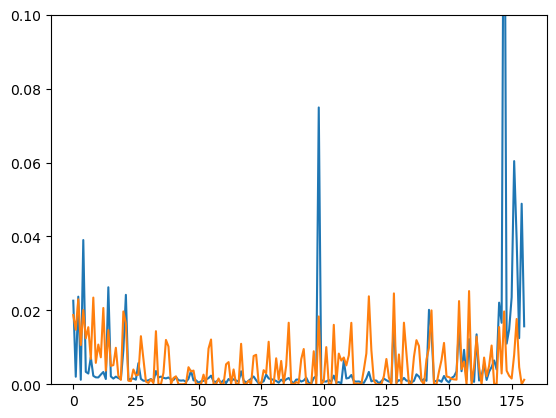

In [11]:
idx = 14
_ = plt.plot(pmf_full[white_matter][idx])
_ = plt.plot(pmf_dipy[white_matter][idx]/pmf_dipy[white_matter][idx].sum())
plt.ylim(0, 0.1)


In [12]:
data, affine, hardi_img = load_nifti(hardi_fname, return_img=True)
labels = load_nifti_data(label_fname)
bvals, bvecs = read_bvals_bvecs(hardi_bval_fname, hardi_bvec_fname)
gtab = gradient_table(bvals, bvecs=bvecs)

seed_mask = labels == 2
white_matter = (labels == 1) | (labels == 2)
seeds = utils.seeds_from_mask(seed_mask, affine, density=1)

response, ratio = auto_response_ssst(gtab, data, roi_radii=10, fa_thr=0.7)
csd_model = ConstrainedSphericalDeconvModel(gtab, response, sh_order_max=6)
csd_fit = csd_model.fit(data, mask=white_matter)

fod = csd_fit.odf(small_sphere)
pmf_dipy = fod.clip(min=0)

In [13]:
from dipy.tracking.stopping_criterion import CmcStoppingCriterion
hardi_fname, hardi_bval_fname, hardi_bvec_fname = get_fnames(name="stanford_hardi")
label_fname = get_fnames(name="stanford_labels")
f_pve_csf, f_pve_gm, f_pve_wm = get_fnames(name="stanford_pve_maps")

data, affine, hardi_img = load_nifti(hardi_fname, return_img=True)
labels = load_nifti_data(label_fname)
bvals, bvecs = read_bvals_bvecs(hardi_bval_fname, hardi_bvec_fname)
gtab = gradient_table(bvals, bvecs=bvecs)


pve_csf_data = load_nifti_data(f_pve_csf)
pve_gm_data = load_nifti_data(f_pve_gm)
pve_wm_data, _, voxel_size = load_nifti(f_pve_wm, return_voxsize=True)

voxel_size = np.average(voxel_size[1:4])
step_size = 0.2

cmc_criterion = CmcStoppingCriterion.from_pve(
    pve_wm_data,
    pve_gm_data,
    pve_csf_data,
    step_size=step_size,
    average_voxel_size=voxel_size,
)

In [14]:
# data, affine, hardi_img = load_nifti(hardi_fname, return_img=True)
# labels = load_nifti_data(label_fname)
# bvals, bvecs = read_bvals_bvecs(hardi_bval_fname, hardi_bvec_fname)
# gtab = gradient_table(bvals, bvecs=bvecs)

# csa_model = CsaOdfModel(gtab, sh_order_max=6)
# gfa = csa_model.fit(data, mask=white_matter).gfa
# stopping_criterion = ThresholdStoppingCriterion(gfa, 0.25)

In [18]:
prob_dg = ProbabilisticDirectionGetter.from_pmf(
    pmf_full, max_angle=35.0, sphere=small_sphere
)
# streamline_generator = LocalTracking(
#     prob_dg, stopping_criterion, seeds, affine, step_size=0.01
# )
from dipy.tracking.local_tracking import LocalTracking, ParticleFilteringTracking

streamline_generator = ParticleFilteringTracking(
    prob_dg,
    cmc_criterion,
    seeds,
    affine,
    max_cross=3,
    step_size=0.5,
    maxlen=10_000,
    pft_back_tracking_dist=3,
    pft_front_tracking_dist=2,
    particle_count=500,
    return_all=False,
    min_wm_pve_before_stopping=1,
)
streamlines = Streamlines(streamline_generator)
sft = StatefulTractogram(streamlines, hardi_img, Space.RASMM)
save_trk(sft, "tractogram_probabilistic_dg_pmf_2.trk")


scene = window.Scene()
scene.add(actor.line(streamlines, colors=colormap.line_colors(streamlines)))
window.record(
    scene=scene, out_path="tractogram_probabilistic_dg_pmf_2.png", size=(800, 800)
)

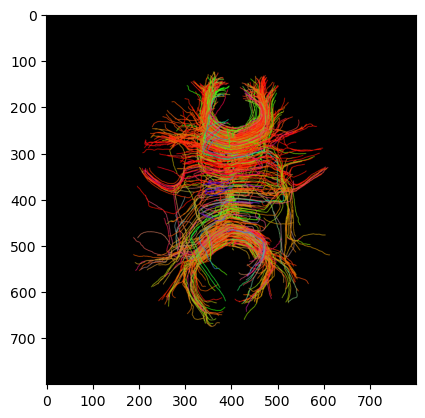

In [19]:
img = plt.imread("tractogram_probabilistic_dg_pmf_2.png")
plt.imshow(img)

In [20]:
# Interactive
window.show(scene)

In [21]:
sft.to_vox()

In [23]:
candidate_sl = sft.streamlines

In [26]:
from os.path import join as pjoin

import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import AxesGrid
import numpy as np

# We'll need to know where the corpus callosum is from these variables:
from dipy.core.gradients import gradient_table
import dipy.core.optimize as opt
from dipy.data import fetch_stanford_tracks, get_fnames
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti, load_nifti_data
from dipy.io.streamline import load_trk
import dipy.tracking.life as life
from dipy.viz import actor, colormap as cmap, window

hardi_fname, hardi_bval_fname, hardi_bvec_fname = get_fnames(name="stanford_hardi")
label_fname = get_fnames(name="stanford_labels")
t1_fname = get_fnames(name="stanford_t1")

data, affine, hardi_img = load_nifti(hardi_fname, return_img=True)
labels = load_nifti_data(label_fname)
t1_data = load_nifti_data(t1_fname)
bvals, bvecs = read_bvals_bvecs(hardi_bval_fname, hardi_bvec_fname)
gtab = gradient_table(bvals, bvecs=bvecs)

cc_slice = labels == 2

  0%|          | 0/71 [00:00<?, ? MB/s]

In [27]:
# Enables/disables interactive visualization
interactive = False

candidate_streamlines_actor = actor.streamtube(
    candidate_sl, colors=cmap.line_colors(candidate_sl)
)
cc_ROI_actor = actor.contour_from_roi(cc_slice, color=(1.0, 1.0, 0.0), opacity=0.5)

vol_actor = actor.slicer(t1_data)

vol_actor.display(x=40)
vol_actor2 = vol_actor.copy()
vol_actor2.display(z=35)

# Add display objects to canvas
scene = window.Scene()
scene.add(candidate_streamlines_actor)
scene.add(cc_ROI_actor)
scene.add(vol_actor)
scene.add(vol_actor2)
window.record(scene=scene, n_frames=1, out_path="life_candidates.png", size=(800, 800))


In [28]:
window.show(scene)

In [30]:
fiber_model = life.FiberModel(gtab)
inv_affine = np.linalg.inv(hardi_img.affine)

fiber_fit = fiber_model.fit(data, candidate_sl, affine=np.eye(4))

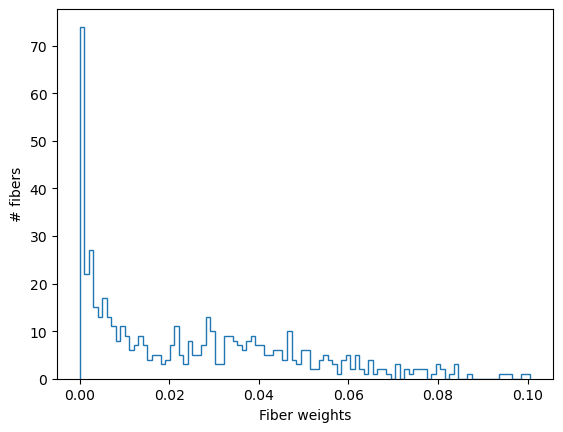

In [31]:
fig, ax = plt.subplots(1)
ax.hist(fiber_fit.beta, bins=100, histtype="step")
ax.set_xlabel("Fiber weights")
ax.set_ylabel("# fibers")
fig.savefig("beta_histogram.png")

In [32]:
optimized_sl = [np.vstack(candidate_sl)[np.where(fiber_fit.beta > 0)[0]]]
scene = window.Scene()
scene.add(actor.streamtube(optimized_sl, colors=cmap.line_colors(optimized_sl)))
scene.add(cc_ROI_actor)
scene.add(vol_actor)
window.record(scene=scene, n_frames=1, out_path="life_optimized.png", size=(800, 800))


In [33]:
window.show(scene)

In [35]:
model_predict = fiber_fit.predict()
model_error = model_predict - fiber_fit.data
model_rmse = np.sqrt(np.mean(model_error[:, 10:] ** 2, -1))

In [36]:
beta_baseline = np.zeros(fiber_fit.beta.shape[0])
pred_weighted = np.reshape(
    opt.spdot(fiber_fit.life_matrix, beta_baseline),
    (fiber_fit.vox_coords.shape[0], np.sum(~gtab.b0s_mask)),
)
mean_pred = np.empty((fiber_fit.vox_coords.shape[0], gtab.bvals.shape[0]))
S0 = fiber_fit.b0_signal

In [37]:
mean_pred[..., gtab.b0s_mask] = S0[:, None]
mean_pred[..., ~gtab.b0s_mask] = (pred_weighted + fiber_fit.mean_signal[:, None]) * S0[
    :, None
]
mean_error = mean_pred - fiber_fit.data
mean_rmse = np.sqrt(np.mean(mean_error**2, -1))

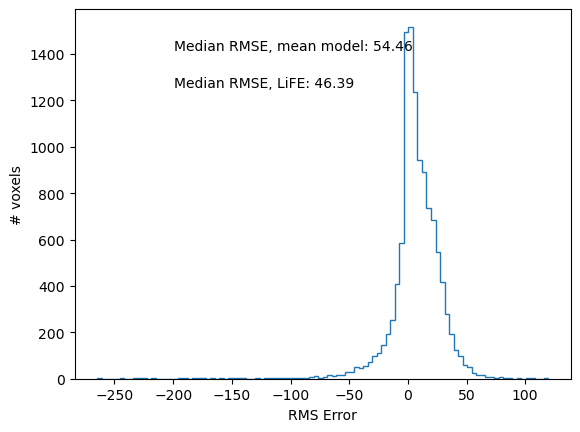

In [38]:
fig, ax = plt.subplots(1)
ax.hist(mean_rmse - model_rmse, bins=100, histtype="step")
ax.text(
    0.2,
    0.9,
    f"Median RMSE, mean model: {np.median(mean_rmse):.2f}",
    horizontalalignment="left",
    verticalalignment="center",
    transform=ax.transAxes,
)
ax.text(
    0.2,
    0.8,
    f"Median RMSE, LiFE: {np.median(model_rmse):.2f}",
    horizontalalignment="left",
    verticalalignment="center",
    transform=ax.transAxes,
)
ax.set_xlabel("RMS Error")
ax.set_ylabel("# voxels")
fig.savefig("error_histograms.png")

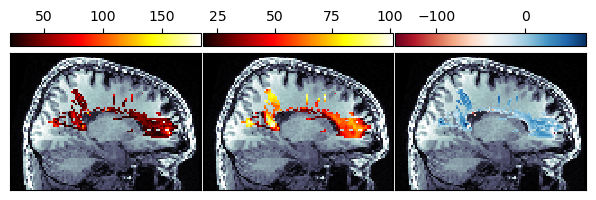

In [39]:
vol_model = np.ones(data.shape[:3]) * np.nan
vol_model[
    fiber_fit.vox_coords[:, 0], fiber_fit.vox_coords[:, 1], fiber_fit.vox_coords[:, 2]
] = model_rmse
vol_mean = np.ones(data.shape[:3]) * np.nan
vol_mean[
    fiber_fit.vox_coords[:, 0], fiber_fit.vox_coords[:, 1], fiber_fit.vox_coords[:, 2]
] = mean_rmse
vol_improve = np.ones(data.shape[:3]) * np.nan
vol_improve[
    fiber_fit.vox_coords[:, 0], fiber_fit.vox_coords[:, 1], fiber_fit.vox_coords[:, 2]
] = mean_rmse - model_rmse
sl_idx = 49
fig = plt.figure()
fig.subplots_adjust(left=0.05, right=0.95)
ax = AxesGrid(
    fig,
    111,
    nrows_ncols=(1, 3),
    label_mode="1",
    share_all=True,
    cbar_location="top",
    cbar_mode="each",
    cbar_size="10%",
    cbar_pad="5%",
)
ax[0].matshow(np.rot90(t1_data[sl_idx, :, :]), cmap=matplotlib.cm.bone)
im = ax[0].matshow(np.rot90(vol_model[sl_idx, :, :]), cmap=matplotlib.cm.hot)
ax.cbar_axes[0].colorbar(im)
ax[1].matshow(np.rot90(t1_data[sl_idx, :, :]), cmap=matplotlib.cm.bone)
im = ax[1].matshow(np.rot90(vol_mean[sl_idx, :, :]), cmap=matplotlib.cm.hot)
ax.cbar_axes[1].colorbar(im)
ax[2].matshow(np.rot90(t1_data[sl_idx, :, :]), cmap=matplotlib.cm.bone)
im = ax[2].matshow(np.rot90(vol_improve[sl_idx, :, :]), cmap=matplotlib.cm.RdBu)
ax.cbar_axes[2].colorbar(im)
for lax in ax:
    lax.set_xticks([])
    lax.set_yticks([])
fig.savefig("spatial_errors.png")